# FinDiff: A Deep Dive into Tabular Diffusion Models 

Welcome to the **Extended FinDiff Tutorial**. While our compact notebook `example.ipynb` offers a quick start using the high-level API, this notebook completely "unrolls" the implementation.

We will build the components from scratch to understand the math and mechanics behind **Denoising Diffusion Probabilistic Models (DDPMs)** applied to mixed-type (categorical and numerical) tabular data.

### What you will learn:
- **Data Preprocessing**: How to map categorical values into continuous embedding spaces.
- **Network Architecture**: Building a time-conditioned MLP Synthesizer with Sinusoidal Embeddings.
- **Diffusion Math**: The forward (noise-adding) and reverse (denoising) processes.
- **Generation & Decoding**: Reversing the embeddings back to discrete categories using Euclidean distance.

First, let's install the required libraries.

In [ ]:
# # install required libraries
!pip3 install sdv #  synthetic data vault library
!pip3 install -U ucimlrepo # UCI machine learning repository library
!pip3 install nbformat # notebook format library

Import required libraries.

In [2]:
# import data science libraries
import numpy as np
import math
from tqdm import tqdm
import pandas as pd
# import pytorch libraries
import torch
from torch.utils.data import DataLoader, Dataset
from torch import nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

# import synthetic data vault libraries
from sdv.metadata import SingleTableMetadata
import sdv.evaluation.single_table as sdv_st
from sdmetrics.visualization import get_column_plot

# import visualisation libraries
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import LabelEncoder, QuantileTransformer
# ipython reload extension for auto-reloading modules
%load_ext autoreload
%autoreload 2

### Experiment Configuration Protocol

This section defines and initializes all hyperparameters, architectural layouts, and environmental controls for the machine learning pipeline. 

* **General System Settings**
  * Controls deterministic reproducibility via global random seed initialization.
  * Dynamically detects hardware availability to assign processing workloads to either CPU or CUDA devices.

* **Data Preprocessing & Encoding Settings**
  * **Categorical Encoding:** Defines the mathematical mapping of discrete categories into a continuous embedding space *(Note: Currently supports `label_encoder` only)*.
  * **Categorical Decoding:** Evaluates the reconstruction methodology to translate latent embeddings back into original categories.
    * **Distance-based (`distance`):** Employs a Nearest-Neighbor lookup to identify the closest valid embedding vector by calculating geometric distance.
    * **Logits-based (`logits`):** Utilizes raw prediction outputs mapped against a probability distribution over a one-hot vector for each category.
  * **Numerical Scaling:** Standardizes continuous features to optimize gradient flow and convergence stability.

* **Neural Network Architecture**
  * Configures the structural backbone (`mlp`, `unet`, or `transformer`), layer dimensions, residual capacity, and activation functions for the underlying neural model.

* **Diffusion Hyperparameters**
  * Isolates generative settings tailored for the diffusion synthesizer, including time-step discretization, embedding dimensionality, and variance schedule constraints ($\beta_{\text{start}}$ to $\beta_{\text{end}}$).

* **Training Loop Parameters**
  * Dictates standard optimization constraints including dataset iteration caps (epochs), batch normalization sizes, and learning rate boundaries.


Init and set experiment parameters. 

In [3]:
# ==============================================================================
# 1. EXPERIMENT CONFIGURATION
# ==============================================================================
config = {
    # --- General System Settings ---
    "seed": 1234,
    "device": torch.device("cuda:0" if torch.cuda.is_available() else "cpu").type,

    # --- Data Preprocessing Settings ---
    # 'label_encoder': Maps categories to embedding space (currently only option supported)
    "cat_encoding": "label_encoder", 
    # 'distance': Uses nearest-neighbor lookup | 'logits': Uses one-hot vectors
    "cat_decoding": "distance",       
    "num_scaling": "standard",

    # --- Neural Network Architecture ---
    "cat_emb_dim": 2,                  # Dimension of categorical embeddings
    "mlp_hidden_dim": 512,             # Number of neurons per layer
    "mlp_num_residual_blocks": 2,      # Number of residual blocks for MLP
    "activation": "lrelu",             # Non-linear activation function

    # --- Diffusion Hyperparameters ---
    "diffusion_steps": 500,            # Lower steps used for fast tutorial demonstration
    "diffusion_beta_start": 1e-4,      # Initial noise schedule value
    "diffusion_beta_end": 0.02,        # Final noise schedule value
    "timestep_emb_dim": 64,            # Dimension of the timestep embedding
    "emb_learnable": False,            # Toggle to learn or freeze categorical embeddings

    # --- Training Loop Parameters ---
    "epochs": 500,                      
    "batch_size": 512,                 
    "learning_rate": 1e-4              
}

# ==============================================================================
# 2. ENVIRONMENT INITIALIZATION
# ==============================================================================
# Example usage: print active device to confirm setup
print(f"Experiment initialized using device: {config['device'].upper()}")


Experiment initialized using device: CPU


### Reproducibility
Set random seeds to ensure our experiments are reproducible.

In [4]:
# set numpy seed
np.random.seed(config["seed"])

if config["device"] == "cuda":
    # set pytorch seed
    torch.manual_seed(config["seed"])

    # set cuda seed
    torch.cuda.manual_seed(config["seed"])

## 1. Data Preparation

For this tutorial, we will use the **Default of Credit Card Clients** dataset from the UCI Machine Learning Repository. This tabular dataset captures demographic factors, history of past monthly payments, and bill statements of credit card clients in Taiwan. It serves as a good benchmark for validating our tabular generative model (**FinDiff**), as it contains a mix of categorical values (e.g., gender, education) and continuous numerical values (e.g., credit limit, bill amounts).

* **Dataset Source:** [UCI Credit Card Dataset](https://uci.edu)
* **Dimensions:** 30,000 instances across 23 features
* **Target:** Binary classification indicator for payment default

We load the features \(X\) and targets \(y\) directly into Pandas DataFrame using the official repository utility:

In [5]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
default_of_credit_card_clients = fetch_ucirepo(id=350)

# data (as pandas dataframes)
X = default_of_credit_card_clients.data.features
y = default_of_credit_card_clients.data.targets

# map X column names to variable names
cols = default_of_credit_card_clients.variables
X.columns = cols[cols["name"].isin(X.columns)]["description"].to_list()
original_data = X.copy()

Inspect the top 10 rows and attribute names of the dataset retreived.

In [6]:
# display top 10 rows
original_data.head(10)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679
5,50000,1,1,2,37,0,0,0,0,0,...,57608,19394,19619,20024,2500,1815,657,1000,1000,800
6,500000,1,1,2,29,0,0,0,0,0,...,445007,542653,483003,473944,55000,40000,38000,20239,13750,13770
7,100000,2,2,2,23,0,-1,-1,0,0,...,601,221,-159,567,380,601,0,581,1687,1542
8,140000,2,3,1,28,0,0,2,0,0,...,12108,12211,11793,3719,3329,0,432,1000,1000,1000
9,20000,1,3,2,35,-2,-2,-2,-2,-1,...,0,0,13007,13912,0,0,0,13007,1122,0


Set numerical and categorical dataset attributes. 

In [7]:
# determine categorical attributes
cat_attrs = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6",
]

# determine numerical attributes
num_attrs = [
    "LIMIT_BAL",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6",
]
# convert categorical attributes to string
original_data[cat_attrs] = original_data[cat_attrs].astype(str)
# convert numerical attributes to float
original_data[num_attrs] = original_data[num_attrs].astype(float)

# 2. Data Transformations
### 2.1 Numerical Transformations

Diffusion models operate natively in continuous spaces and perform best on normally distributed data. 
We use `QuantileTransformer(output_distribution='normal')` to map arbitrary numerical features to a Gaussian space.

In [8]:
# init the quantile transformation
num_scaler = QuantileTransformer(output_distribution='normal', random_state=config["seed"])

# fit transformation to numerical attributes
num_scaler.fit(original_data[num_attrs])

# transform numerical attributes
train_num_scaled = num_scaler.transform(original_data[num_attrs])

### 2.2 Categorical Encoding

Prepares categorical features for the diffusion model by:
- prefixing each categorical value with its column name to preserve feature identity,
- fitting a shared `LabelEncoder` over all categorical tokens, during the forward pass they will be embedded into continuous vectors,
- transforming the categorical dataframe into integer-encoded values,
- building lookup maps for each categorical column’s unique tokens and cardinality so the model can correctly embed and decode categorical features.

In [9]:
# 1. Prepend column names to categorical values for correct encoding by LabelEncoder.
train_cat = original_data[cat_attrs].copy()
for col in cat_attrs:
    # Vectorized string concatenation
    train_cat[col] = f"{col}__" + train_cat[col].astype(str)

# 2. Encode categorical attributes using LabelEncoder.
cat_encoder = LabelEncoder()
cat_encoder.fit(train_cat.values.flatten())
train_cat_scaled = train_cat.apply(cat_encoder.transform).values

# 3. Create mappings for categorical attributes to their unique values and cardinality.
categorical_mapping = {
    col: set(train_cat[col]) for col in cat_attrs
}
categorical_cardinality = {
    col: len(set(train_cat[col])) for col in cat_attrs
}
embedding_mapping = {
    col: np.where(np.isin(cat_encoder.classes_, list(categorical_mapping[col])))[0]
    for col in cat_attrs
}

### 2.3 Label Encoding
If the dataset contains a label and conditional generation is used, the a target label (`y`) can optionally be encoded and mapped to integer-encoded values.

In [10]:
label_encoder = LabelEncoder()
# fit on values; LabelEncoder accepts 1d array-like
label_encoder.fit(y.astype(object).to_numpy().ravel())
label = label_encoder.transform(y.astype(object).to_numpy().ravel())
label_classes = list(label_encoder.classes_)
label_cardinality = len(label_classes)

### FinDiffDataset

`FinDiffDataset` is a small PyTorch `Dataset` wrapper for tabular FinDiff training data.

**It stores:**
- `cat_dataset`: integer-encoded categorical columns (`LongTensor`)
- `num_dataset`: scaled continuous columns (`FloatTensor`)
- `labels`: optional target labels (`LongTensor`)

**Behavior:**
- `__len__` returns the number of samples from `num_dataset`
- `__getitem__` returns a dictionary with keys `"cat"` and `"num"`
- If `labels` are provided, it also returns `"label"`

This dataset is used with `DataLoader` to batch categorical IDs, numeric inputs, and optional labels together for the diffusion training loop.


In [11]:
class FinDiffDataset(Dataset):
    """PyTorch Dataset for FinDiff tabular data."""

    # define the class constructor
    def __init__(self, cat_dataset, num_dataset, labels=None):

        # set datasets
        self.cat_dataset = cat_dataset
        self.num_dataset = num_dataset
        self.labels = labels

    # define the length method
    def __len__(self):

        # returns the number of samples
        return len(self.num_dataset)

    # define the get item method
    def __getitem__(self, index):

        sample ={
            "cat": self.cat_dataset[index, :],
            "num": self.num_dataset[index, :]
        }
        if self.labels is not None:
            sample["label"] = self.labels[index]
      
        # return dataset and label batch
        return sample
    

### Prepare Torch DataLoader
Convert numerical and categorical attributes as well as the labels to tensors and initialize the DataLoader via custom FinDIffDataset.

In [12]:
# convert training data and labels to tensors
X_train_cat = torch.LongTensor(train_cat_scaled)
X_train_num = torch.FloatTensor(train_num_scaled)
y_train_torch = torch.LongTensor(label)

# init fedtabdiff dataset
train_set = FinDiffDataset(
    cat_dataset=X_train_cat, 
    num_dataset=X_train_num, 
    labels=y_train_torch
)
# init the training data loader
train_dataloader = DataLoader(
    dataset=train_set, 
    batch_size=config["batch_size"], 
    shuffle=True)

## 3. Implement the FinDiff model

Standard diffusion models (like those used for images) operate purely in continuous space. Tabular data poses a unique challenge because it contains both **continuous** and **discrete (categorical)** variables.

To bridge this gap, FinDiff maps categorical tokens into a continuous $\mathbb{R}^d$ space using an Embedding layer. Once all features are continuous, we can apply standard Gaussian noise.

### Mathematical Formulation
Let $\mathbf{x}_0$ be a preprocessed tabular record. The forward diffusion process adds noise over $T$ steps:
$$q(\mathbf{x}_t | \mathbf{x}_{t-1}) = \mathcal{N}(\mathbf{x}_t; \sqrt{1 - \beta_t} \mathbf{x}_{t-1}, \beta_t \mathbf{I})$$

By reparameterization, we can sample $\mathbf{x}_t$ directly at any arbitrary timestep $t$:
$$\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t}\epsilon, \quad \epsilon \sim \mathcal{N}(0, \mathbf{I})$$

Our goal is to train a neural network $\epsilon_\theta(\mathbf{x}_t, t)$ to predict the injected noise $\epsilon$. The loss is:
$$\mathcal{L}_{MSE} = \mathbb{E}_{t, \mathbf{x}_0, \epsilon} \left[ \| \epsilon - \epsilon_\theta(\mathbf{x}_t, t) \|^2 \right]$$

### 3.1 FinDiff MLP Backbone and Time Embedding

The core network components used by the FinDiff synthesizer, it serves as the deep feature extractor in our denoiser:

- `MLPBackbone`
    - Accepts the concatenated noisy tabular input and conditioning embedding.
    - Projects the combined vector into a hidden feature space.
    - Passes the features through a sequence of residual blocks.
    - Outputs a tensor matching the original input dimensionality for noise prediction.

- `ResidualBlock`
    - A simple feedforward residual module.
    - Consists of two linear layers with a `SiLU` activation in between.
    - Adds the original input back to the transformed output.

- `SinusoidalPositionEmbeddings`
    - Generates fixed sinusoidal time embeddings for diffusion timesteps.
    - Produces a vector of alternating sine and cosine values for each input timestep.
    - Ensures the model can condition on the current diffusion step.

In [13]:
class MLPBackbone(nn.Module):
    """
    MLP Backbone.
    Accepts concatenated x_t and a pre-computed conditioning embedding.
    
    Args:
        num_features (int): The dimension of the input tabular features.
        cond_dim (int): The dimension of the conditioning embedding.
        hidden_dim (int, optional): Hidden layer dimension. Defaults to 256.
        num_blocks (int, optional): Number of residual blocks. Defaults to 4.
    """
    def __init__(self, num_features, cond_dim, hidden_dim=256, num_blocks=4):
        super().__init__()
        
        # Input projection now takes features + condition embedding
        self.input_proj = nn.Linear(num_features + cond_dim, hidden_dim)
        
        self.blocks = nn.ModuleList([
            ResidualBlock(hidden_dim) for _ in range(num_blocks)
        ])
        
        self.output_proj = nn.Linear(hidden_dim, num_features)

    def forward(self, x, cond_emb):
        # x shape: [batch_size, num_features]
        # cond_emb shape: [batch_size, cond_dim]
        
        inputs = torch.cat([x, cond_emb], dim=1) # [B, num_features + cond_dim]
        
        h = self.input_proj(inputs)
        for block in self.blocks:
            h = block(h)
            
        output = self.output_proj(h)
        return output


class ResidualBlock(nn.Module):
    """A simple residual block for the MLP."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.layer1 = nn.Linear(hidden_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.activation = nn.SiLU()

    def forward(self, x):
        identity = x
        out = self.activation(self.layer1(x))
        out = self.layer2(out)
        return identity + out
    
class SinusoidalPositionEmbeddings(nn.Module):
    """
    Standard sinusoidal time embedding module.
    
    Args:
        dim (int): The dimension of the sinusoidal embeddings. Must be even.
    """
    def __init__(self, dim):
        super().__init__()
        assert dim % 2 == 0, "Sinusoidal dimension must be even"
        self.dim = dim

    def forward(self, time):
        """
        Forward pass for sinusoidal position embeddings.
        
        Args:
            time (torch.Tensor): Timesteps of shape [batch_size].
            
        Returns:
            torch.Tensor: Sinusoidal embeddings of shape [batch_size, dim].
        """
        # time shape: [batch_size]
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        # embeddings shape: [batch_size, dim]
        return embeddings

### 3.2. The Synthesizer Network (Conditioned Denoiser)

The `FinDiffSynthesizer` PyTorch module, which is the conditional denoising model for tabular diffusion. It includes:

- an initializer that:
    - builds sinusoidal timestep embeddings
    - optionally adds label conditioning via an embedding layer
    - creates a shared categorical embedding table
    - sets up an unconditional embedding for classifier-free guidance
    - instantiates an MLP backbone for noise prediction
    - optionally builds extra categorical logits heads when using `cat_decoding='logits'`
- helper methods:
    - `get_x_cat_emb()` to return the learned categorical embedding matrix
    - `embed_x_cat()` to map input categorical token IDs into flattened embedding vectors
- a `forward()` method that:
    - computes time and optional label conditioning embeddings
    - combines them into a conditioning vector
    - passes the noisy input through the backbone to predict the noise
    - returns either raw noise predictions or both noise and per-category logits depending on the decoding mode

**Time Embedding**: In diffusion models, the network must know *which* timestep $t$ it is denoising. We use **Sinusoidal Position Embeddings**:
$$ PE_{(t, 2i)} = \sin(t / 10000^{2i/d}) $$
$$ PE_{(t, 2i+1)} = \cos(t / 10000^{2i/d}) $$

**Class Conditioning**: If labels are provided, we learn an embedding for the class label and add it to the time embedding. This allows for **conditional generation**.

In [14]:

class FinDiffSynthesizer(nn.Module):
    """
    A conditional diffusion model for tabular data with swappable backbones.
    
    Args:
        num_cols_dim (int): The number of numerical features in the tabular data.
        cat_vocab (dict): Dictionary mapping categorical column names to their unique token indices.
        cat_emb_dim (int, optional): Dimension for categorical embeddings. Defaults to 2.
        n_classes (int | None, optional): The number of classes for conditional generation. Defaults to None.
        embedding_learned (bool, optional): Whether the categorical embeddings are learnable. Defaults to False.
        time_embed_dim (int | None, optional): The dimension for time and label embeddings. Defaults to 64.
        backbone_type (str, optional): The neural network backbone to use ('mlp', 'transformer', or 'unet'). Defaults to 'mlp'.
        backbone_config (dict | None, optional): A dictionary of hyperparameters for the chosen backbone. Defaults to None.
        cat_decoding (str, optional): The method for categorical decoding ('distance' or 'logits'). Defaults to 'distance'.
    """
    def __init__(
            self, 
            num_cols_dim: int, 
            cat_vocab: dict,
            cat_emb_dim: int = 2,
            n_classes: int | None = None, 
            embedding_learned: bool = False,
            time_embed_dim: int | None = None,
            backbone_config: dict | None = None,
            cat_decoding: str = 'distance'
        ):
        super().__init__()

        self.cat_decoding = cat_decoding
        self.num_cols_dim = num_cols_dim
        n_cat_tokens = sum(len(tokens) for tokens in cat_vocab.values())
        self.dim_input = num_cols_dim + len(cat_vocab) * cat_emb_dim

        if backbone_config is None:
            backbone_config = {}

        if time_embed_dim is None:
            time_embed_dim = 64

        # --- 1. Conditioning Embeddings ---
        
        # Time embedding
        self.time_embed_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_embed_dim),
            nn.Linear(time_embed_dim, time_embed_dim),
            nn.SiLU()
        )
        # Label embedding
        if n_classes is not None:
            self.label_embed = nn.Embedding(n_classes, time_embed_dim)
        # Categorical embedding
        self.x_cat_emb = nn.Embedding(num_embeddings=n_cat_tokens, embedding_dim=cat_emb_dim)
        self.x_cat_emb.weight.requires_grad = embedding_learned
        if cat_decoding == 'logits':
            self.x_cat_emb.weight.requires_grad = True
        
        # Unconditional embedding (for Classifier-Free Guidance)
        # We learn this as a parameter
        self.uncond_embed = nn.Parameter(torch.randn(1, time_embed_dim))

        # --- 2. Define Backbone ---
        self.backbone = MLPBackbone(
            num_features=self.dim_input,
            cond_dim=time_embed_dim,
            hidden_dim=backbone_config.get('mlp_hidden_dim', 256),
            num_blocks=backbone_config.get('mlp_num_residual_blocks', 2)
        )

        if self.cat_decoding == 'logits':
            # self.cat_head = nn.Linear(self.dim_input, cond_embed_dim)
            self.cat_head = nn.Sequential(
                nn.Linear(self.dim_input, time_embed_dim),
                nn.SiLU(),
                nn.Linear(time_embed_dim, time_embed_dim)
            )
            self.x_cat_logits = nn.ModuleList(
                [nn.Linear(time_embed_dim, len(tokens)) for tokens in cat_vocab.values()]
            )            

    def get_x_cat_emb(self):
        """ Extract embedding vectors 

        Returns:
            tensor: embedding vectors
        """
        return self.x_cat_emb.weight.data

    def embed_x_cat(self, x_cat):
        """ Perform embedding mapping for categorical attributes

        Args:
            x_cat (tensor): categorical tokens

        Returns:
            tensor: embeddings
        """

        # perform embedding mapping and then reshape
        x_cat_emb = self.x_cat_emb(x_cat)
        x_cat_emb = x_cat_emb.view(-1, x_cat_emb.shape[1] * x_cat_emb.shape[2])
        return x_cat_emb
    
    def forward(self, x, timesteps, label=None):
        """
        Forward pass of the denoising model.
        
        Args:
            x (torch.Tensor): The noisy input data (x_t) of shape [batch_size, num_features]
            timesteps (torch.Tensor): The timesteps of shape [batch_size]
            label (torch.Tensor, optional): 
                The conditional labels of shape [batch_size].
                If None, uses unconditional embedding (for CFG).
                
        Returns:
            torch.Tensor or tuple: 
                If cat_decoding is 'distance', returns predicted noise of shape [batch_size, num_features].
                If cat_decoding is 'logits', returns a tuple containing predicted noise and categorical logits.
        """
        
        # --- 1. Compute Conditioning Embedding ---
        
        # [batch_size, cond_embed_dim]
        t_emb = self.time_embed_mlp(timesteps)
        
        # [batch_size, cond_embed_dim]
        if label is not None:
            l_emb = self.label_embed(label)
        else:
            # Use unconditional embedding for all samples in batch
            l_emb = self.uncond_embed.repeat(x.shape[0], 1)
            
        # Combine embeddings
        cond_emb = t_emb + l_emb

        # --- 2. Pass to Backbone ---
        
        # The backbone predicts the noise
        x_pred = self.backbone(x, cond_emb)

        if self.cat_decoding == 'distance':
            return x_pred
        elif self.cat_decoding == 'logits':
            cat_head = self.cat_head(x_pred)
            cat_head += t_emb

            # get logits
            cat_logits = [cat_logit(cat_head) for cat_logit in self.x_cat_logits]
            return x_pred, cat_logits
        else:
            raise ValueError(f"Unknown cat_decoding: {self.cat_decoding}")

## 3.3 Diffusion Denoising

The `BaseDiffuser` handles the math of the forward and reverse diffusion processes and the underlying denoising mechanism of FinDiff model. It establishes:

**Forward Diffusion Process**
- Defines how Gaussian noise is progressively added to data over $T$ timesteps (**`add_gauss_noise`**)
- The process follows: $q(\mathbf{x}_t | \mathbf{x}_{t-1}) = \mathcal{N}(\mathbf{x}_t; \sqrt{1 - \beta_t} \mathbf{x}_{t-1}, \beta_t \mathbf{I})$
- Provides a closed-form solution to sample at any arbitrary timestep $t$: $\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t}\epsilon$

**Reverse Diffusion Process**
- The core denoising mechanism that reconstructs clean data from noise (**`p_sample_gauss`**)
- Trains a neural network $\epsilon_\theta(\mathbf{x}_t, t)$ to predict the injected noise
- Implements the reverse step using the reparameterization formula:
$$\mu_\theta(\mathbf{x}_t, t) = \frac{1}{\sqrt{\alpha_t}} \left( \mathbf{x}_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}} \epsilon_\theta(\mathbf{x}_t, t) \right)$$

**Training Objective**
- Loss function: $\mathcal{L}_{MSE} = \mathbb{E}_{t, \mathbf{x}_0, \epsilon} \left[ \| \epsilon - \epsilon_\theta(\mathbf{x}_t, t) \|^2 \right]$
- Trains the model to predict noise at random timesteps, enabling effective denoising

This foundation justifies why the `BaseDiffuser` class implements `add_gauss_noise()` for forward process and `p_sample_gauss()` for reverse process.

In [15]:

class BaseDiffuser:
    """
    Base diffuser for tabular diffusion operations.
    Handles the noise scheduling and forward/reverse diffusion steps.
    """

    def __init__(
            self, 
            total_steps: int = 1000, 
            beta_start: float = 1e-4, 
            beta_end: float = 0.02, 
            device: str = 'cpu',
            scheduler_scale: bool = False
        ):
        """Base constructor for diffusion operations

        Args:
            total_steps (int, optional): total diffusion steps. Defaults to 1000.
            beta_start (float), optional): beta start value. Defaults to 1e-4.
            beta_end (float, optional): beta end value. Defaults to 0.02.
            device (str, optional): either cpu or cuda. Defaults to 'cpu'.
            scheduler_scale (bool, optional): whether to scale the scheduler. Defaults to False.
        """

        self.total_steps = total_steps
        self.beta_start = beta_start
        self.beta_end = beta_end
        self.device = device
        self.scheduler_scale = scheduler_scale

        self.alphas, self.betas = self.prepare_noise_schedule()
        self.alphas_hat = torch.cumprod(self.alphas, dim=0)

    def prepare_noise_schedule(self):
        """ build a noise scheduler based on the provided scheduler type, total steps, and start/end betas

        Returns:
            Tensor: corrensponding alphas and betas
        """
        if self.scheduler_scale:
            scale = max(self.total_steps, 1000) / self.total_steps
        else:
            scale = 1.0
        self.beta_start = scale * self.beta_start
        self.beta_end = scale * self.beta_end
        betas = self.init_scheduler()
        alphas = 1.0 - betas

        return alphas.to(self.device), betas.to(self.device)

    def sample_timesteps(self, n: int):
        """sample list of random timesteps

        Args:
            n (int): number of timesteps to generate

        Returns:
            Tensor: generated list of random timesteps
        """
        t = torch.randint(low=0, high=self.total_steps, size=(n,), device=self.device)
        return t

    def add_gauss_noise(self, x_num: torch.Tensor, t: torch.Tensor):
        """ Add gaussian noise to the input data given a specific timestep value

        Args:
            x_num (Tensor): input data tensor
            t (Tensor): list of timesteps

        Returns:
            Tensor: a data tensor with injected noise (x_noise_num) and noise itself (x_noise)
        """
        # numeric attributes
        sqrt_alpha_hat = torch.sqrt(self.alphas_hat[t])[:, None]
        sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alphas_hat[t])[:, None]
        noise_num = torch.randn_like(x_num)
        x_noise_num = sqrt_alpha_hat * x_num + sqrt_one_minus_alpha_hat * noise_num
        return x_noise_num, noise_num

    def p_sample_gauss(self, model_out: torch.Tensor, z_norm: torch.Tensor, t: torch.Tensor):
        """ Sampling or denoising step

        Args:
            model_out: trained model used for noise removal
            z_norm (Tensor): initial data tensor
            t (Tensor): list of timesteps

        Returns:
            Tensor: denoised tensor
        """
        sqrt_alpha_t = torch.sqrt(self.alphas[t])[:, None]
        betas_t = self.betas[t][:, None]
        sqrt_one_minus_alpha_hat_t = torch.sqrt(1 - self.alphas_hat[t])[:, None]
        epsilon_t = torch.sqrt(self.betas[t])[:, None]

        random_noise = torch.randn_like(z_norm)
        random_noise[t == 0] = 0.0

        model_mean = ((1 / sqrt_alpha_t) * (z_norm - (betas_t * model_out / sqrt_one_minus_alpha_hat_t)))
        z_norm = model_mean + (epsilon_t * random_noise)

        return z_norm

    # define scheduler initialization
    def init_scheduler(self):
        """
        Initialize the scheduler.
        
        Returns:
            callable: Scheduler function.
        """
        return torch.linspace(self.beta_start, self.beta_end, self.total_steps)

## 3.4. Initialize the FinDiff Model

Preparation of the diffusion-based tabular synthesizer for training:

- creates a `FinDiffSynthesizer` using the configured input dimensions, categorical vocabulary, class count, embedding size, timestep embedding size, and MLP backbone hyperparameters;
- moves the model to the selected compute device (`cpu` or `cuda`);
- initializes a `BaseDiffuser` with the configured number of diffusion steps, beta schedule values, and noise scheduler.

Together, these components define the model and diffusion process that will be used in the training loop.

In [16]:
# init the synthesizer model
synthesizer = FinDiffSynthesizer(
    num_cols_dim=len(num_attrs),
    cat_vocab=categorical_mapping,
    n_classes=label_cardinality,
    cat_emb_dim=config["cat_emb_dim"],
    time_embed_dim=config["timestep_emb_dim"],
    embedding_learned=config["emb_learnable"],
    backbone_config={
        "mlp_hidden_dim": config["mlp_hidden_dim"],
        "mlp_num_residual_blocks": config["mlp_num_residual_blocks"]
    },
    cat_decoding=config["cat_decoding"]
)

# push model to compute device
synthesizer = synthesizer.to(config["device"])

# init the diffuser
diffuser = BaseDiffuser(
    total_steps=config["diffusion_steps"],
    beta_start=config["diffusion_beta_start"],
    beta_end=config["diffusion_beta_end"],
    device=config["device"]
)

Init optimizer, scheduler and loss function.

In [17]:
# int mean-squared-error loss
if config["cat_decoding"] == 'logits':
    loss_fnc_cat = nn.CrossEntropyLoss(reduction='none').to(config["device"])
loss_fnc = nn.MSELoss(reduction='none').to(config["device"])

# determine synthesizer model parameters
parameters = filter(lambda p: p.requires_grad, synthesizer.parameters())

# init the adam model optimizer
optimizer = Adam(parameters, lr=config["learning_rate"])

# init the cosine learning rate scheduler
lr_scheduler = CosineAnnealingLR(optimizer, T_max=config["epochs"])
        
# placeholder for training history
training_history = {"train_loss": []}

## FinDiff training loop.

- Samples random diffusion timesteps for the current batch.
- Embeds categorical token IDs into continuous vectors and concatenates them with numeric features.
- Adds Gaussian noise to the combined tabular data at the sampled timesteps.
- Runs the noisy data through the synthesizer to predict noise:
    - If `cat_decoding == 'distance'`, computes the MSE loss directly between predicted and true noise.
    - If `cat_decoding == 'logits'`, computes both numeric MSE loss and categorical cross-entropy loss across categorical heads.
- Performs backpropagation and optimizer updates.
- Updates the learning rate scheduler and records the average training loss for the epoch.
- Updates the progress bar description with the current epoch and training loss.

In [18]:
# init the training progress bar
pbar = tqdm(iterable=range(config["epochs"]), position=0, leave=True)

# iterate over training epochs
for epoch in pbar:

    batch_losses = []
    # iterate over distinct mini-batches
    for batch in train_dataloader:
        # set network in training mode
        synthesizer.train()
        # push batch to compute device
        batch_cat = batch["cat"].to(config["device"])
        batch_num = batch["num"].to(config["device"])
        if "label" in batch:
            batch_y = batch["label"].to(config["device"])
        else:                
            batch_y = None

        # sample timestamps t
        timesteps = diffuser.sample_timesteps(n=batch_cat.shape[0])

        # get cat embeddings
        batch_cat_emb = synthesizer.embed_x_cat(x_cat=batch_cat)
        # concat cat & num
        batch_cat_num = torch.cat((batch_cat_emb, batch_num), dim=1)

        # add noise
        batch_noise_t, noise_t = diffuser.add_gauss_noise(x_num=batch_cat_num, t=timesteps)

        # conduct forward encoder/decoder pass
        if config["cat_decoding"] == 'distance':
            predicted_noise = synthesizer(x=batch_noise_t, timesteps=timesteps, label=batch_y)

            # compute train loss
            train_losses = loss_fnc(
                input=noise_t,
                target=predicted_noise,
            ).sum(dim=1).mean()

        elif config["cat_decoding"] == 'logits':
            predicted_noise_num, cat_logits = synthesizer(x=batch_noise_t, timesteps=timesteps, label=batch_y)

            # compute num loss
            num_loss = loss_fnc(
                input=noise_t,
                target=predicted_noise_num,
            ).sum(dim=1)

            # compute cat loss
            cat_loss = 0
            for i in range(len(cat_logits)):
                # get target cat column and adjust for min index of column in embedding mapping
                cat_min_idx = list(embedding_mapping.values())[i].min()
                batch_cat_target = (batch_cat[:, i] - cat_min_idx).long()
                cat_loss += loss_fnc_cat(cat_logits[i], batch_cat_target)
            
            # total loss
            train_losses = (num_loss + cat_loss).mean()

        else:
            raise ValueError(f"Unknown cat_decoding: {config['cat_decoding']}")

        # reset encoder and decoder gradients
        optimizer.zero_grad()

        # run error back-propagation
        train_losses.backward()

        # optimize encoder and decoder parameters
        optimizer.step()

        # collect rec error losses
        batch_losses.append(train_losses.detach().cpu().numpy())

    # average of rec errors
    total_losses_mean = np.mean(np.array(batch_losses))

    # update learning rate according to the scheduler
    lr_scheduler.step()

    # update training history
    training_history["train_loss"].append(total_losses_mean)
    
    # determine mean training round loss
    pbar.set_description(f"Epoch {epoch + 1:04d} | Train Loss: {total_losses_mean:.6f}")


Epoch 0500 | Train Loss: 6.102873: 100%|██████████| 500/500 [05:02<00:00,  1.66it/s]


Visualize training loss progression.

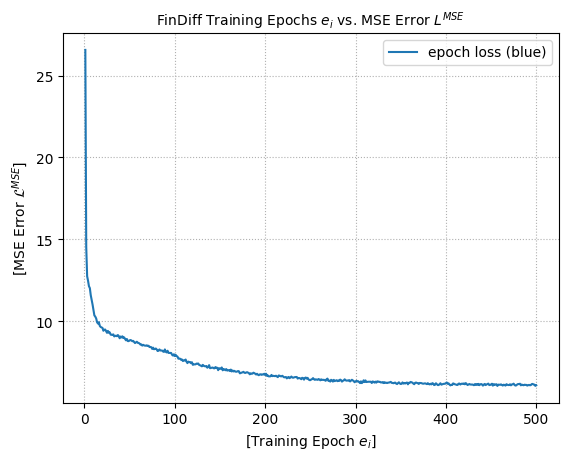

In [19]:
total_losses = training_history["train_loss"]
# prepare plot
fig = plt.figure()
ax = fig.add_subplot(111)

# add grid
ax.grid(linestyle='dotted')

# plot the training epochs vs. the epochs' classification error
ax.plot(np.array(range(1, len(total_losses)+1)), total_losses, label='epoch loss (blue)')

# add axis legends
ax.set_xlabel('[Training Epoch $e_i$]', fontsize=10)
ax.set_ylabel('[MSE Error $\mathcal{L}^{MSE}$]', fontsize=10)

# set plot legend
plt.legend(loc='upper right', numpoints=1, fancybox=True)

# add plot title
plt.title('FinDiff Training Epochs $e_i$ vs. MSE Error $L^{MSE}$', fontsize=10);

## 4. Generate Data using the FinDiff model

To generate new synthetic data, we:
1. Sample pure Gaussian noise $\mathbf{x}_T \sim \mathcal{N}(0, \mathbf{I})$ with the desired shape.
2. Iteratively apply the reverse process `p_sample_gauss` from step $T$ down to $0$.
3. The final output $\mathbf{x}_0$ contains both the synthesized continuous variables and the synthesized categorical embeddings.

In [20]:
# get dimension of encoded data
dim_input = synthesizer.dim_input
n_samples = len(y_train_torch)
label_torch = y_train_torch.to(device=config["device"])

sample_list = []

# init random noise for this chunk
x_t = torch.randn((label_torch.size(0), dim_input), device=config["device"])

# run the reverse diffusion for this chunk
pbar = tqdm(iterable=reversed(range(0, diffuser.total_steps)), leave=False)

with torch.no_grad():
    # iterate over diffusion steps
    for i in pbar:
        pbar.set_description(f"SAMPLING STEP: {i:4d}/{diffuser.total_steps:4d}")

        t = torch.full((label_torch.size(0),), i, dtype=torch.long, device=config["device"])

        if config["cat_decoding"] == 'distance':
            model_out = synthesizer(x_t.float(), t, label_torch)
        elif config["cat_decoding"] == 'logits':
            model_out, cat_logits = synthesizer(x_t.float(), t, label_torch)
        else:
            raise ValueError(f"Unknown cat_decoding: {config['cat_decoding']}")

        x_t = diffuser.p_sample_gauss(model_out, x_t, t)

x_0 = x_t.cpu().numpy()

### 4.1 Decoding Categorical Embeddings via Euclidean Distance

The generated sample matrix contains continuous approximations of our categorical embeddings. We decode them back to discrete categories by finding the nearest neighbor (using Euclidean distance) in our original learned/initialized embedding lookup matrix.

$$\text{Decoded Category} = \arg\min_{k} \| \mathbf{x}_{cat} - \text{Emb}(k) \|_2$$

Afterward, we inverse-transform the scalers and label encoders to get human-readable data.

Note: This implementation is for learning purposes, a memory-optimized version designed for large datasets can be found in `model.py`.

In [21]:
# decode samples for the chunk and collect
cat_dim = config["cat_emb_dim"] * len(cat_attrs)

# split sample into numeric and categorical parts
samples_num = x_0[:, cat_dim:]
samples_cat = x_0[:, :cat_dim]

# get embedding lookup matrix
embedding_lookup = synthesizer.get_x_cat_emb().cpu()

# reshape back to batch_size * n_dim_cat * cat_emb_dim
samples_cat = samples_cat.reshape(-1, len(cat_attrs), config["cat_emb_dim"])

# compute pairwise distances
distances = torch.cdist(x1=embedding_lookup, x2=torch.Tensor(samples_cat))

# get the closest distance based on the embeddings that belong to a column category
z_cat_df = pd.DataFrame(index=range(len(samples_cat)), columns=cat_attrs)

nearest_dist_df = pd.DataFrame(index=range(len(samples_cat)), columns=cat_attrs)

# iterate over categorical attributes
for attr_idx, attr_name in enumerate(cat_attrs):

    attr_emb_idx = list(embedding_mapping[attr_name])
    attr_distances = distances[:, attr_emb_idx, attr_idx]

    nearest_values, nearest_idx = torch.min(attr_distances, dim=1)
    nearest_idx = nearest_idx.cpu().numpy()

    z_cat_df[attr_name] = np.array(attr_emb_idx)[nearest_idx]  # need to map emb indices back to column indices
    nearest_dist_df[attr_name] = nearest_values.cpu().numpy()

z_cat_df = z_cat_df.apply(cat_encoder.inverse_transform)

# remove prepended column name from every category value
for col in cat_attrs:
    z_cat_df[col] = z_cat_df[col].astype(str).str.split("__", n=1).str[-1]


### 4.2 Denormalize Numeric Features back to the data scaling

In [22]:
# denormalize numeric attributes
z_norm_upscaled = num_scaler.inverse_transform(samples_num)
z_norm_df = pd.DataFrame(z_norm_upscaled, columns=num_attrs)

/Users/timur/Documents/Projects/23_Table_Diffusion/07_github_open/FinDiff/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but QuantileTransformer was fitted with feature names



### 4.3 Concatenate Categorical and Numeric Features

In [23]:
synt_dataset = pd.concat([z_cat_df, z_norm_df], axis=1)
synt_dataset.head(10)

,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,1,1,2,33,-2,3,-2,-2,-2,-2,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
1,1,2,2,36,3,2,2,3,0,0,...,31162.824219,27926.621094,22563.289062,19437.792969,0.000000,3014.855225,0.000000,0.000000,2013.821533,0.00000
2,1,1,2,40,0,0,2,0,0,0,...,65848.445312,50971.429688,52079.703125,43015.464844,11123.996094,0.000000,2651.698486,1496.951416,2500.000000,2000.00000
3,2,1,1,41,0,0,0,0,0,0,...,61353.632812,75547.671875,78470.187500,82177.195312,3933.485840,3385.062500,3060.879639,6006.614258,5000.000000,4302.85498
4,2,1,2,22,0,1,2,2,2,2,...,121890.351562,108709.023438,65573.679688,42084.812500,4992.402344,4621.111816,3705.184814,0.000000,0.000000,2800.00000
5,2,2,2,51,1,2,2,0,0,0,...,8897.813477,17703.318359,25326.902344,12146.755859,1116.838989,0.000000,2000.000000,915.542114,0.000000,0.00000
6,1,2,1,63,0,0,0,0,0,0,...,57395.636719,45394.753906,30573.699219,19317.365234,4874.038086,3000.000000,2000.000000,1744.911377,1000.000000,0.00000
7,1,2,2,38,0,0,0,0,0,-1,...,2940.903809,1178.663330,1308.212402,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
8,2,2,2,56,1,-2,-2,-2,-1,-2,...,196.088806,499.453827,3803.344971,0.000000,0.000000,0.000000,0.000000,1303.635498,0.000000,0.00000
9,1,3,1,50,-2,-2,-2,-2,-2,-2,...,17828.162109,12838.791016,1322.972656,9999.258789,2188.062744,2691.435303,3161.038330,1907.319580,10000.000000,0.00000


## 5. Evaluating the Generated Data
We use the `sdv` library to evaluate how closely our synthetic dataset matches the original.

In [24]:
# build a metadata for evaluation (from SDV)
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=original_data)

# generate quality report
quality_report = sdv_st.evaluate_quality(
    real_data=original_data, synthetic_data=synt_dataset, metadata=metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 23/23 [00:00<00:00, 66.54it/s]| 
Column Shapes Score: 93.95%

(2/2) Evaluating Column Pair Trends: |██████████| 253/253 [00:01<00:00, 197.68it/s]|
Column Pair Trends Score: 93.26%

Overall Score (Average): 93.61%



### Visualizing Feature Fidelity

To assess the quality of the generated tabular data, we compare the distributions of individual columns between our real training dataset and the generated synthetic output. 

The cell below plots a distribution comparison (`distplot`) for the continuous numerical column **`PAY_AMT2`** (Payment Amount 2) to evaluate how well FinDiff has learned the underlying shape, density, and skewness of the original data.


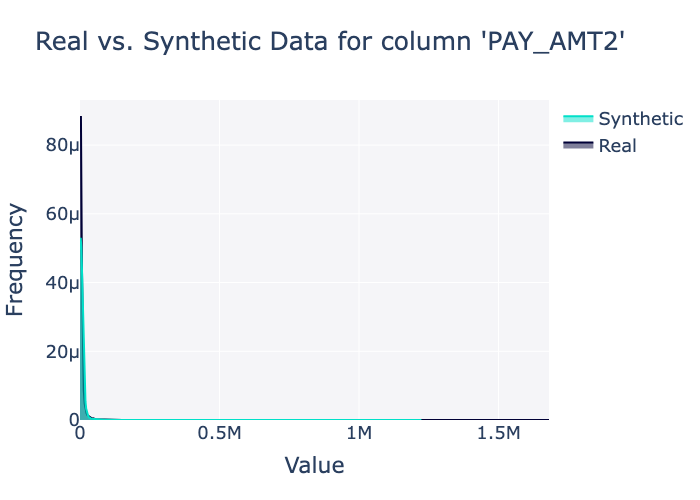

In [25]:
fig = get_column_plot(
    real_data=original_data,
    synthetic_data=synt_dataset,
    column_name="PAY_AMT2",
    plot_type="distplot",
)

fig.show(renderer="png")


### Visualizing Categorical Value Fidelity

While numerical columns check for shape and skewness, categorical columns evaluate the model's ability to capture discrete probability distributions. 

The cell below generates a comparative bar chart (`bar`) for the **`EDUCATION`** column. This plot reveals how accurately FinDiff reproduces the relative frequencies, proportions, and presence of discrete categories compared to the original dataset.


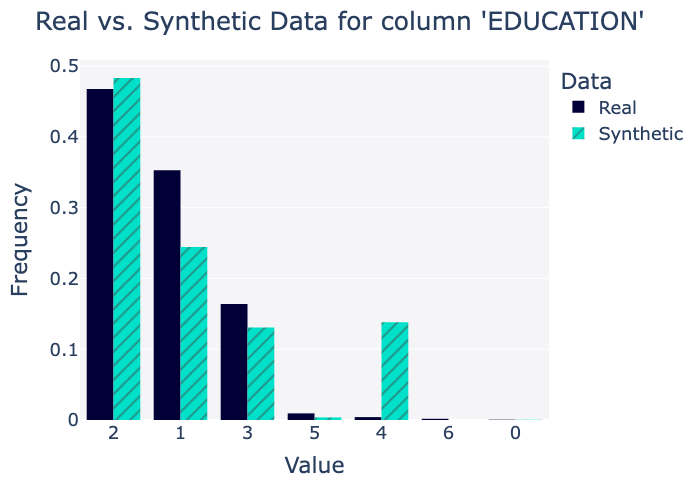

In [26]:
fig = get_column_plot(
    real_data=original_data,
    synthetic_data=synt_dataset,
    column_name="EDUCATION",
    plot_type="bar",
)

fig.show(renderer="png")


### Global Column Shapes Evaluation

To quantify the model's performance globally across all features, we evaluate the overall statistical similarity between the real and synthetic columns. 

The cell below extracts the **"Column Shapes"** visualization from our evaluation suite. This plot directly corresponds to the **"Fidelity Column"** metrics discussed in the FinDiff paper, aggregating the shape similarity scores across all individual numerical and categorical attributes to provide a high-level view of generation fidelity.


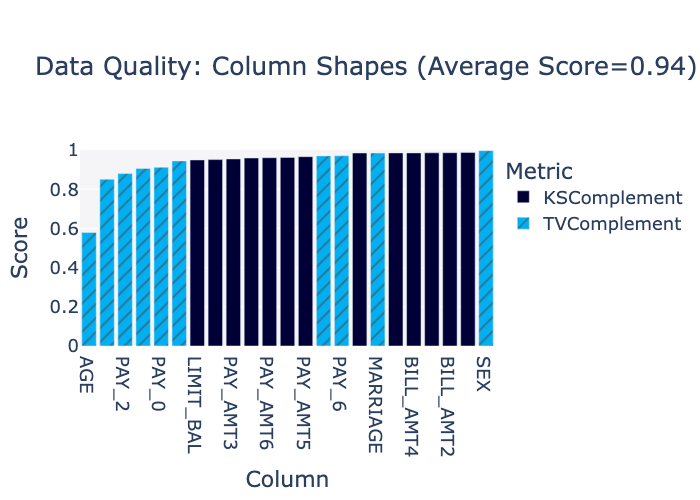

In [27]:
# plot Column Shapes -> referred to the "Fidelity Column" in the paper
fig = quality_report.get_visualization(property_name="Column Shapes")
fig.show(renderer="png")

### Global Column Pair Trends Evaluation

While individual column shapes verify marginal distributions, evaluating column pairs measures the model's capacity to preserve complex cross-feature dependencies, correlations, and interactions.

The cell below extracts the **"Column Pair Trends"** visualization from our evaluation suite. This plot directly corresponds to the **"Fidelity Row"** metrics discussed in the FinDiff paper, summarizing how accurately the model captures correlations between all pairs of features relative to the ground truth.


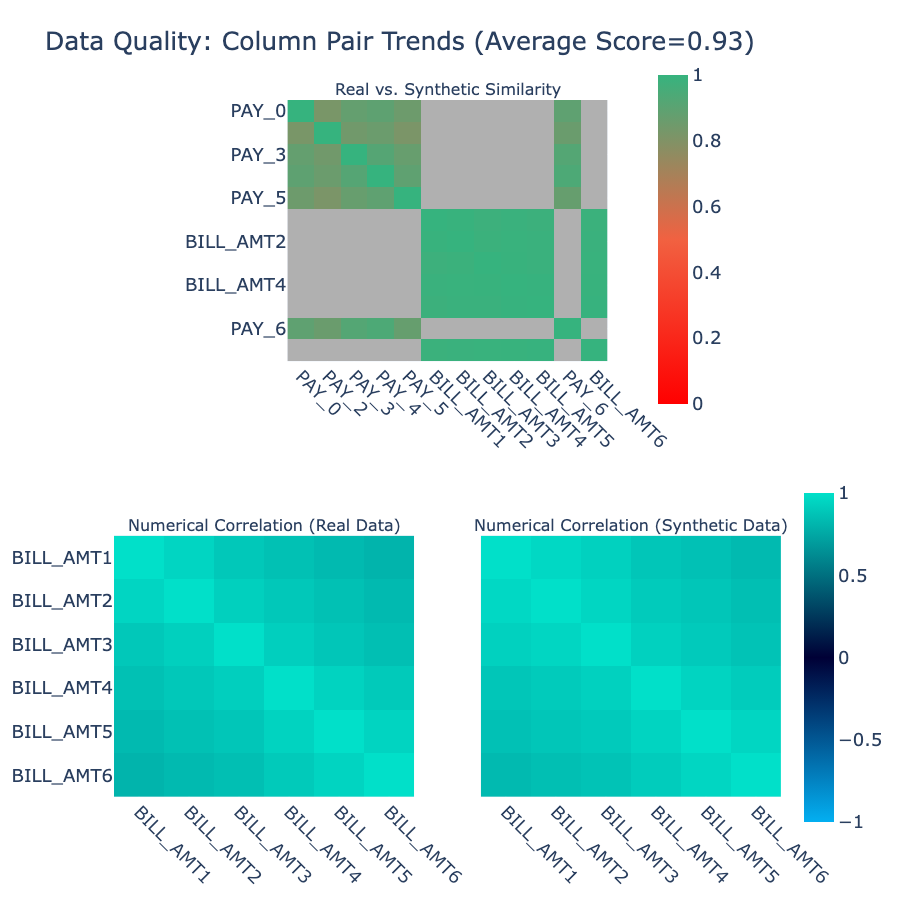

In [28]:
# plot Column Pair Trends -> referred to the "Fidelity Row" in the paper
fig = quality_report.get_visualization(property_name="Column Pair Trends")
fig.show(renderer="png")